<div style="background-color: #e0f7fa; padding: 15px; border-radius: 8px;">

# Cyber Threat Detection Project: Real-Time Anomaly Detection and Analysis

<p>Cybersecurity is critical for organizations to protect their sensitive data from evolving cyber threats. The <strong>MITRE ATT&CK Framework</strong> provides a comprehensive knowledge base of adversary tactics, techniques, and procedures (TTPs). Analyzing attack patterns helps in detecting and mitigating potential threats effectively.</p>

### Real-Life Use Case
<p>This project detects and analyzes real-time cybersecurity threats within an organization's infrastructure. By monitoring system logs, network traffic, and security events, it helps identify anomalous behaviors, which can be indicative of a cyberattack.</p>

### Tools and Techniques Used
<p><strong>MITRE ATT&CK Framework</strong>: A comprehensive model of adversary behaviors.</p>
<p><strong>Apache Spark</strong>: A distributed computing framework for big data processing.</p>
<p><strong>Isolation Forest</strong>: A machine learning model used for anomaly detection.</p>
<p><strong>Hadoop</strong>: An open-source framework for processing and storing large datasets, crucial for handling high-volume data.</p>
<p><strong>Matplotlib & Plotly</strong>: Libraries used for visualizing data and anomalies.</p>

### Importance
<p>This project not only helps organizations detect cybersecurity threats in real-time but also integrates Hadoop for scalable data storage and processing. Hadoop’s ability to handle large datasets ensures that even organizations dealing with massive volumes of data can benefit from anomaly detection and threat mitigation, enhancing overall security posture.</p>

</div>


In [ ]:
# Cell 1: Import necessary libraries
import pandas as pd
from pyspark.sql import SparkSession
from sklearn.ensemble import IsolationForest
import joblib
import plotly.express as px
import matplotlib.pyplot as plt


In [2]:
# Cell 2: Load and preprocess MITRE ATT&CK data
# Load the dataset
df = pd.read_csv("data/mitre_attack_data.csv")

# Drop rows with missing values
df = df.dropna()

# Convert 'timestamp' to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display the first few rows of the dataset
df.head()


,timestamp,attacker_name,tactic,technique,attack_vector,severity,affected_system,ip_address,user_account,region,status
0,2022-08-13 21:55:30.530108,Stephanie Bowman,Privilege Escalation,Taint Shared Content,Phishing,High,see,181.92.190.51,qpeterson,Africa,Failed
1,2020-12-06 15:23:37.937963,Paul Rich,Initial Access,PowerShell,Web,High,tend,28.110.219.116,wmartinez,US,Successful
2,2022-01-10 07:32:41.505921,Caleb Collins,Initial Access,Phishing,USB,High,he,116.118.48.34,michaelreese,Australia,Failed
3,2022-09-18 14:18:04.589698,Angel Burton,Credential Access,Phishing,Phishing,Critical,southern,69.66.89.106,alvaradodeborah,Australia,Successful
4,2024-07-26 17:08:20.230460,Jeffrey Walsh,Exfiltration,Network Sniffing,Web,High,first,24.150.22.83,natalieparks,South America,Successful


In [3]:
# Cell 3: Initialize Spark session and create a Spark DataFrame
spark = SparkSession.builder.appName("CyberThreatDetection").getOrCreate()

# Convert the Pandas DataFrame to Spark DataFrame
spark_df = spark.createDataFrame(df)

# Show first few rows of the Spark DataFrame
spark_df.show(5)


24/11/06 16:30:55 WARN Utils: Your hostname, cybersec resolves to a loopback address: 127.0.1.1; using 192.168.47.132 instead (on interface ens33)
24/11/06 16:30:55 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
24/11/06 16:30:56 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


+--------------------+----------------+--------------------+--------------------+-------------+--------+---------------+--------------+---------------+-------------+----------+
|           timestamp|   attacker_name|              tactic|           technique|attack_vector|severity|affected_system|    ip_address|   user_account|       region|    status|
+--------------------+----------------+--------------------+--------------------+-------------+--------+---------------+--------------+---------------+-------------+----------+
|2022-08-13 21:55:...|Stephanie Bowman|Privilege Escalation|Taint Shared Content|     Phishing|    High|            see| 181.92.190.51|      qpeterson|       Africa|    Failed|
|2020-12-06 15:23:...|       Paul Rich|      Initial Access|          PowerShell|          Web|    High|           tend|28.110.219.116|      wmartinez|           US|Successful|
|2022-01-10 07:32:...|   Caleb Collins|      Initial Access|            Phishing|          USB|    High|           

In [4]:
# Cell 4: Register Spark DataFrame as a temporary SQL table
spark_df.createOrReplaceTempView("cyber_threats")

# Query for the most frequent attack techniques used
result = spark.sql("""
    SELECT technique, COUNT(*) AS frequency
    FROM cyber_threats
    GROUP BY technique
    ORDER BY frequency DESC
    LIMIT 10
""")

# Show the result
result.show()


+--------------------+---------+
|           technique|frequency|
+--------------------+---------+
|            Phishing|      104|
|Command and Scrip...|      101|
|          Ransomware|       98|
|  Credential Dumping|       95|
|Spearphishing Att...|       95|
|Access Token Mani...|       94|
|    Network Sniffing|       92|
|Exploitation of V...|       87|
|Taint Shared Content|       79|
|          PowerShell|       78|
+--------------------+---------+



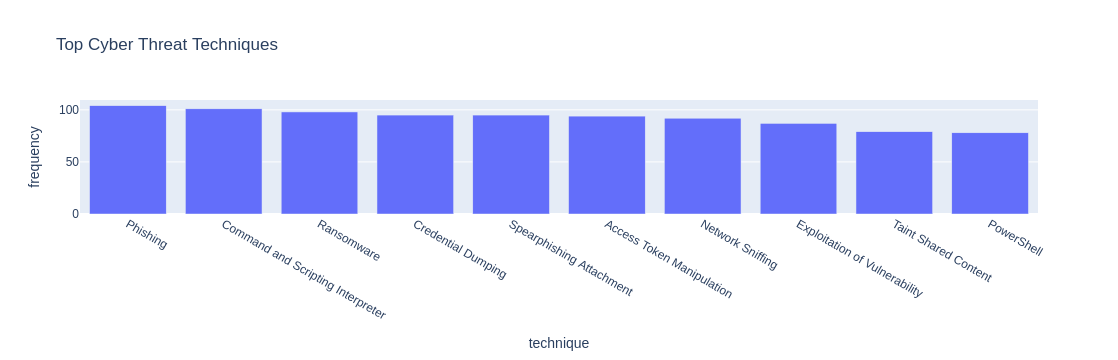

In [11]:
# Cell 5: Visualize Top Threat Techniques using Plotly
# Convert result to Pandas DataFrame for visualization
top_threats = result.toPandas()

# Create a bar chart for top threats by frequency
fig = px.bar(top_threats, x='technique', y='frequency', title='Top Cyber Threat Techniques')
fig.show()


In [6]:
# Cell 6: Anomaly Detection with Isolation Forest
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder

# Convert severity to numerical values
severity_map = {'High': 3, 'Critical': 4, 'Medium': 2, 'Low': 1}
df.loc[:, 'severity_num'] = df['severity'].map(severity_map)

# Encode the 'attack_vector' and 'region' columns numerically
df.loc[:, 'attack_vector_num'] = LabelEncoder().fit_transform(df['attack_vector'])
df.loc[:, 'region_num'] = LabelEncoder().fit_transform(df['region'])

# Extract features based on timestamp
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.loc[:, 'hour'] = df['timestamp'].dt.hour
df.loc[:, 'day'] = df['timestamp'].dt.day
df.loc[:, 'month'] = df['timestamp'].dt.month

# Select relevant features for anomaly detection
data_for_detection = df[['severity_num', 'attack_vector_num', 'region_num', 'hour', 'day', 'month']]  # Features for model

# Initialize Isolation Forest model
model = IsolationForest(contamination=0.05)

# Fit the model and predict anomalies
df['anomaly'] = model.fit_predict(data_for_detection)

# Filter anomalies (marked as -1)
anomalies = df[df['anomaly'] == -1]
print(f"Anomalies detected: {anomalies.shape[0]}")


Anomalies detected: 50


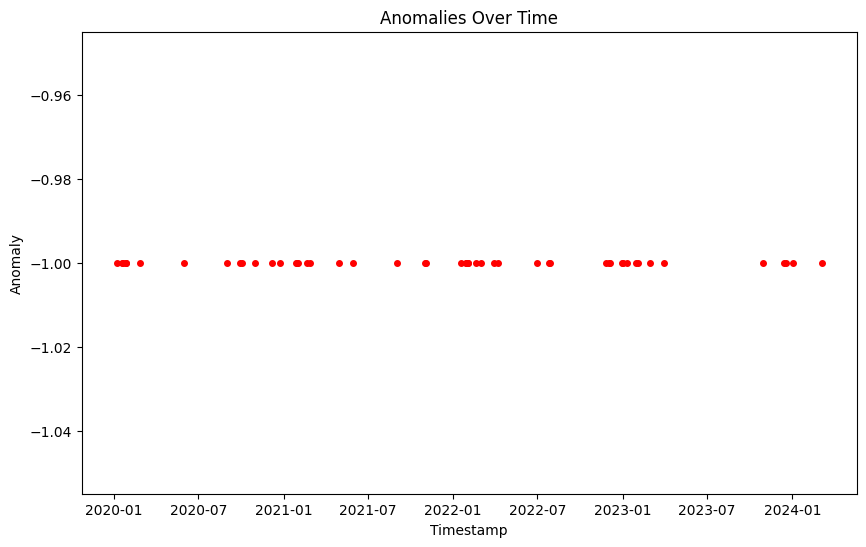

In [7]:
# Cell 7: Visualize Anomalies Over Time using Matplotlib

# Ensure 'timestamp' is in datetime format for anomalies DataFrame
anomalies = anomalies.copy()  # Create a copy to avoid SettingWithCopyWarning
anomalies.loc[:, 'timestamp'] = pd.to_datetime(anomalies['timestamp'])

# Plot anomalies over time
plt.figure(figsize=(10, 6))
plt.plot(anomalies['timestamp'], anomalies['anomaly'], 'ro', markersize=4)
plt.title("Anomalies Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Anomaly")
plt.show()


In [8]:
# Cell 8: Save the Isolation Forest Model
# Save the trained model to disk
joblib.dump(model, 'models/isolation_forest_model.pkl')


['models/isolation_forest_model.pkl']

In [9]:
# Cell 9: Save the Anomalies to a CSV File
# Save the detected anomalies to a CSV file
anomalies.to_csv("data/anomalies_detected.csv", index=False)


In [10]:
# Cell 10: Simulate Big Data Operations using RDD

# Using PySpark to simulate counting frequency of attack techniques
rdd = spark.sparkContext.parallelize(df['technique'].tolist())

# Count frequency of techniques using RDD
technique_counts = rdd.countByValue()

# Displaying the counts as a DataFrame for better readability
technique_counts_df = pd.DataFrame(list(technique_counts.items()), columns=['Technique', 'Count'])

# Sort by count in descending order and display
technique_counts_df = technique_counts_df.sort_values(by='Count', ascending=False)

# Display the top 10 most frequent techniques
technique_counts_df.head(10)


,Technique,Count
2,Phishing,104
4,Command and Scripting Interpreter,101
7,Ransomware,98
8,Spearphishing Attachment,95
10,Credential Dumping,95
5,Access Token Manipulation,94
3,Network Sniffing,92
9,Exploitation of Vulnerability,87
0,Taint Shared Content,79
1,PowerShell,78


<div style="background-color: #ffe0e6; padding: 15px; border-radius: 8px;">

### Conclusion
<p>This project highlights the power of integrating data science tools with cybersecurity frameworks to enhance threat detection. By using <strong>Python</strong> and its extensive libraries such as <strong>pandas</strong>, <strong>scikit-learn</strong>, <strong>Matplotlib</strong>, and <strong>Plotly</strong> within <strong>Jupyter Notebook</strong>, we created an accessible and effective workflow for anomaly detection. The addition of <strong>Apache Spark</strong> and <strong>Hadoop</strong> enables scalable big data handling, making this system robust even for large-scale enterprise environments. These tools together provide a comprehensive, adaptable solution for real-time cybersecurity threat analysis and mitigation.</p>

</div>
